In [27]:
from scipy.stats import mannwhitneyu
from scipy.stats import wilcoxon
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import matplotlib.patches as mpatches
from statsmodels.stats.multitest import multipletests

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/closest_contacts_1mm.csv')
df1['condition'] = 'Group'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed-pseudo/closest_contacts_1mm.csv')
df2['condition'] = 'Shuffle'

df = pd.concat([df1, df2], ignore_index=True)


PALETTE = {
    "Group": '#63859c',     
    "Shuffle": '#b3b3b3'
}

HUE_ORDER = ["Group", "Shuffle"]

Mann–Whitney U = 66548.000
p-value = 4.6806e-08


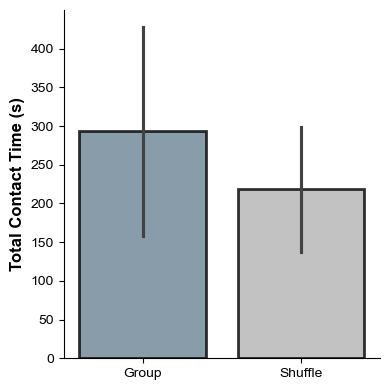

In [28]:
pairs_long = (
    df[['condition', 'file', 'frame', 'Interaction Pair']]
    .assign(
        track=lambda d: (
            d['Interaction Pair']
            .astype(str)
            .str.replace(r'[\(\)\[\]\s]', '', regex=True)   # remove (), [], spaces
            .str.split(',')                                 # -> ['0','1']
        )
    )
    .explode('track')
)

pairs_long['track'] = pairs_long['track'].astype(int)


grouped = (
    pairs_long.groupby(['file', 'condition', 'track'])
    .size()
    .reset_index(name='count')
)


gh = grouped.loc[grouped['condition'] == 'Group', 'count']
si = grouped.loc[grouped['condition'] == 'Shuffle', 'count']

u, p = mannwhitneyu(gh, si, alternative='two-sided')

print(f"Mann–Whitney U = {u:.3f}")
print(f"p-value = {p:.4e}")



plt.figure(figsize=(4,4))
ax = sns.barplot(data=grouped, x='condition', y='count', hue='condition', legend=False, linewidth=2, errorbar='sd', palette=PALETTE, order=HUE_ORDER, edgecolor='black',alpha=0.8)

plt.xlabel('', fontsize=12, fontweight='bold')
plt.ylabel('Total Contact Time (s)', fontsize=12, fontweight='bold')


sns.despine()

plt.tight_layout()

plt.ylim(0, None)
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-1/ghXpseudo/total-contact-type.pdf', 
            format='pdf', bbox_inches='tight')
plt.show()


Mann-Whitney U = 789.0, p = 0.0027


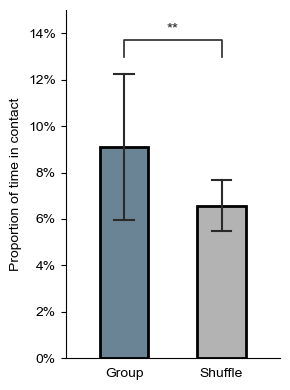

In [29]:
# ===================== PROPORTION OF TIME IN CONTACT PER LARVA (overall) =====================
# Same logic as FIGURE-2/group-v-iso/proportion-of-time.ipynb
import matplotlib.ticker as mticker

bouts_group = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/interaction_type_bout.csv')
bouts_group['condition'] = 'Group'

bouts_shuffle = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed-pseudo/interaction_type_bout.csv')
bouts_shuffle['condition'] = 'Shuffle'

bouts = pd.concat([bouts_group, bouts_shuffle], ignore_index=True)

# --- Helper: merge overlapping intervals and return total covered frames ---
def covered_frames(intervals):
    """Given a list of (start, end) tuples, return total frames covered after merging overlaps."""
    merged = []
    for start, end in sorted(intervals):
        if merged and start <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], end))
        else:
            merged.append([start, end])
    return sum(e - s + 1 for s, e in merged)

# --- Melt so each larva gets its own rows ---
# fps = 1, recording = 3600 s
TOTAL_SECONDS = 3600

bouts_melted = pd.melt(
    bouts,
    id_vars=['file', 'condition', 'start_frame', 'end_frame'],
    value_vars=['track_1', 'track_2'],
    value_name='larva'
).drop(columns='variable')

# --- Per larva: merge overlapping bouts, sum true covered frames ---
proportion_overall = (
    bouts_melted
    .groupby(['condition', 'file', 'larva'])
    .apply(lambda g: covered_frames(zip(g['start_frame'], g['end_frame'])))
    .reset_index(name='contact_seconds')
)
proportion_overall['proportion'] = proportion_overall['contact_seconds'] / TOTAL_SECONDS

# --- Average across larvae per video ---
per_video_overall = (
    proportion_overall
    .groupby(['condition', 'file'])['proportion']
    .mean()
    .reset_index()
)

group_vals   = per_video_overall[per_video_overall['condition'] == 'Group']['proportion'].values
shuffle_vals = per_video_overall[per_video_overall['condition'] == 'Shuffle']['proportion'].values

stat, p = mannwhitneyu(group_vals, shuffle_vals, alternative='two-sided')
print(f'Mann-Whitney U = {stat:.1f}, p = {p:.4f}')

def p_to_stars_time(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

fig, ax = plt.subplots(figsize=(3, 4))

# error bars = mean ± SD across videos
sns.barplot(data=per_video_overall, x='condition', y='proportion', hue='condition',
            order=HUE_ORDER, hue_order=HUE_ORDER, palette=PALETTE, legend=False,
            errorbar=('sd'), width=0.5, edgecolor='black', linewidth=2, 
            capsize=0.2, err_kws={'color': '#2a2a2a', 'linewidth': 1.5}, ax=ax)

# Significance bracket
y_max = max(
    per_video_overall[per_video_overall['condition'] == c]['proportion'].mean() +
    per_video_overall[per_video_overall['condition'] == c]['proportion'].std(ddof=1)
    for c in HUE_ORDER
)   # top of the mean + SD error bar, so the bracket sits above it
y_bracket = y_max * 1.12
y_tip     = y_max * 1.06
stars     = p_to_stars_time(p)

ax.plot([0, 0, 1, 1], [y_tip, y_bracket, y_bracket, y_tip],
        color='#2a2a2a', linewidth=1.2)
ax.text(0.5, y_bracket * 1.01, stars, ha='center', va='bottom',
        fontsize=11 if stars != 'ns' else 9, color='#2a2a2a')

ax.set_xlabel('')
ax.set_ylabel('Proportion of time in contact')
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(0, 0.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(bottom=False)
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-1/ghXpseudo/contact_proportion_overall.pdf', bbox_inches='tight')
plt.show()


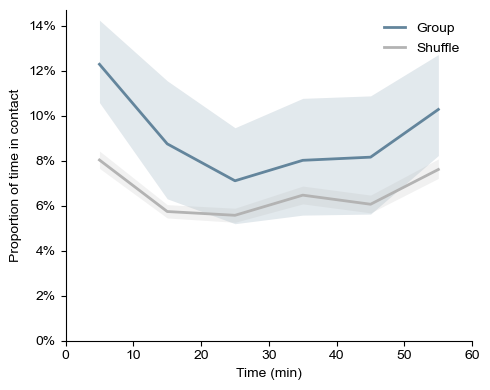

In [30]:
# ===================== PROPORTION OF TIME IN CONTACT PER LARVA OVER TIME =====================
# Same logic as FIGURE-2/group-v-iso/proportion-of-time.ipynb (uses bouts + covered_frames from the cell above)
# fps = 1 so start_frame == second; assign each bout to the bin its start_frame falls in
BIN_SIZE = 600
TOTAL_SECONDS = 3600

bouts_binned = bouts.copy()
bouts_binned['time_bin'] = (bouts_binned['start_frame'] // BIN_SIZE) * BIN_SIZE  # bin labels: 0, 600, 1200, 1800, 2400, 3000

bouts_melted_bins = pd.melt(
    bouts_binned,
    id_vars=['file', 'condition', 'start_frame', 'end_frame', 'time_bin'],
    value_vars=['track_1', 'track_2'],
    value_name='larva'
).drop(columns='variable')

# Per larva per bin: merge overlapping bouts within each bin, sum true covered frames
proportion_binned = (
    bouts_melted_bins
    .groupby(['condition', 'file', 'larva', 'time_bin'])
    .apply(lambda g: covered_frames(zip(g['start_frame'], g['end_frame'])))
    .reset_index(name='contact_seconds')
)
proportion_binned['proportion'] = proportion_binned['contact_seconds'] / BIN_SIZE

# Fill zeros for larvae with no contact in a bin, then average per video
all_larvae = proportion_binned[['condition', 'file', 'larva']].drop_duplicates()
all_bins   = pd.DataFrame({'time_bin': sorted(proportion_binned['time_bin'].unique())})
full_index = all_larvae.merge(all_bins, how='cross')

proportion_binned_full = (
    full_index
    .merge(proportion_binned, on=['condition', 'file', 'larva', 'time_bin'], how='left')
    .fillna({'contact_seconds': 0, 'proportion': 0})
)

per_video_binned = (
    proportion_binned_full
    .groupby(['condition', 'file', 'time_bin'])['proportion']
    .mean()
    .reset_index()
)

per_video_binned['time_min'] = (per_video_binned['time_bin'] + BIN_SIZE / 2) / 60  # bin midpoint in minutes

fig, ax = plt.subplots(figsize=(5, 4))

# shaded band = 95% CI across videos per bin
sns.lineplot(data=per_video_binned, x='time_min', y='proportion', hue='condition',
             hue_order=HUE_ORDER, palette=PALETTE, errorbar=('ci', 95),
             linewidth=2, err_kws={'alpha': 0.18, 'linewidth': 0}, ax=ax)

ax.set_xlabel('Time (min)')
ax.set_ylabel('Proportion of time in contact')
ax.set_xlim(0, 60)
ax.set_ylim(0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, title=None, handlelength=1.5)
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-1/ghXpseudo/contact_proportion_over_time.pdf', bbox_inches='tight')
plt.show()


  interaction_type  n_Group  n_Shuffle  u_stat         p_raw  median_Group  \
0        body_body       10        100     0.0  2.063174e-07      0.021537   
1        body_head       10        100    53.0  3.442421e-06      0.172815   
2        body_tail       10        100     0.0  2.063174e-07      0.079020   
3        head_head       10        100  1000.0  2.063174e-07      0.235344   
4        head_tail       10        100  1000.0  2.063174e-07      0.435103   
5        tail_tail       10        100     0.0  2.063044e-07      0.061348   

   median_Shuffle  delta_median   p_corrected  passes_multiple_test_correction  
0        0.076168      0.054631  2.475809e-07                             True  
1        0.207800      0.034986  3.442421e-06                             True  
2        0.209814      0.130795  2.475809e-07                             True  
3        0.129402     -0.105942  2.475809e-07                             True  
4        0.250478     -0.184625  2.475809e-07   

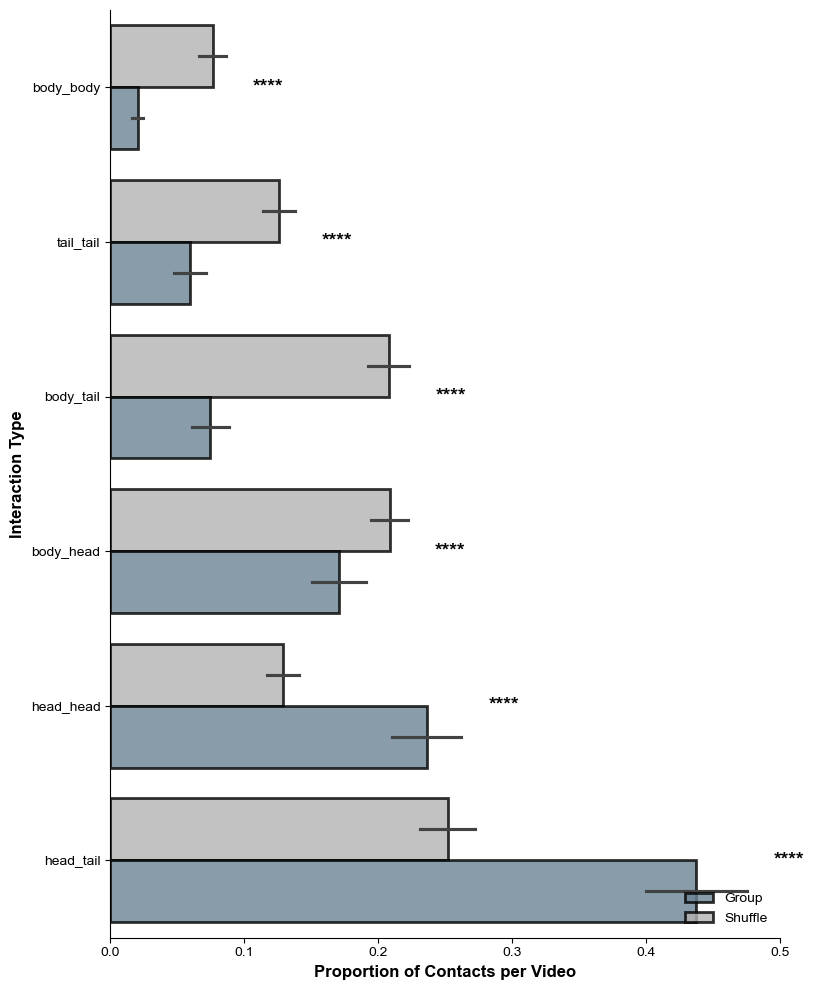

In [31]:
# Count contact frames per video + interaction type, then turn into a proportion per video
counts = (
    df.groupby(['condition', 'file', 'Closest Interaction Type'])
    .size()
    .unstack(fill_value=0)          # videos x interaction types, 0 where a type never happened
)

proportions = counts.div(counts.sum(axis=1), axis=0)   # each video's row sums to 1

grouped = (
    proportions
    .stack()
    .reset_index(name='proportion'))


    
results = []

for interaction, sub in grouped.groupby("Closest Interaction Type"):
    gh = sub.loc[sub["condition"] == "Group", "proportion"]
    pseudo = sub.loc[sub["condition"] == "Shuffle", "proportion"]

    # skip if one group is missing (safety)
    if gh.empty or pseudo.empty:
        print(f"WARNING: skipping {interaction} - missing a condition")
        continue

    u, p = mannwhitneyu(gh, pseudo, alternative="two-sided")

    results.append({
        "interaction_type": interaction,
        "n_Group": len(gh),
        "n_Shuffle": len(pseudo),
        "u_stat": u,
        "p_raw": p,
        "median_Group": gh.median(),
        "median_Shuffle": pseudo.median(),
        "delta_median": pseudo.median() - gh.median()
    })

stats_df = pd.DataFrame(results)
assert not stats_df.empty, f"No stats computed - check condition labels: {grouped['condition'].unique()}"

# --- multiple comparisons correction (FDR) ---
passed, p_corr, _, _ = multipletests(
    stats_df["p_raw"],
    alpha=0.05,
    method="fdr_bh"
)

stats_df["p_corrected"] = p_corr
stats_df["passes_multiple_test_correction"] = passed

print(stats_df)


# --- ADD THIS BLOCK RIGHT HERE ---
def p_to_stars(p):
    if p <= 1e-4:
        return "****"
    if p <= 1e-3:
        return "***"
    if p <= 1e-2:
        return "**"
    if p <= 5e-2:
        return "*"
    return ""

# IMPORTANT: use the SAME label source as your plot x-axis
star_map = dict(
    zip(stats_df["interaction_type"], stats_df["p_corrected"].apply(p_to_stars))
)



# order: least-occurring overall first (nearest y=0)
SWAP_PAIR = ('head_head', 'body_head')   # these two are swapped in the order

order = (
    grouped.groupby('Closest Interaction Type')['proportion']
    .mean()
    .sort_values()
    .index.tolist()
)

a, b = SWAP_PAIR
if a in order and b in order:
    i, j = order.index(a), order.index(b)
    order[i], order[j] = order[j], order[i]
else:
    print(f"WARNING: {SWAP_PAIR} not both present in {order}")

# move body_head to sit directly below body_tail on the plot
MOVE, BELOW = 'body_head', 'body_tail'
if MOVE in order and BELOW in order:
    order.remove(MOVE)
    order.insert(order.index(BELOW) + 1, MOVE)

plt.figure(figsize=(8,10))
ax = sns.barplot(data=grouped, y='Closest Interaction Type', x='proportion', order=order, hue='condition', hue_order = HUE_ORDER[::-1], edgecolor='black', linewidth=2, errorbar='sd', palette=PALETTE, alpha=0.8)

plt.ylabel('Interaction Type', fontsize=12, fontweight='bold')
plt.xlabel('Proportion of Contacts per Video', fontsize=12, fontweight='bold')

sns.despine()
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], frameon=False, title=None, loc="lower right")   # keep legend as Group, Shuffle

# plt.title('Interaction Type (Closest Node)', fontsize=16, fontweight='bold')

plt.tight_layout()

plt.xlim(0, 0.5)

# --- ADD STARS HERE ---
tick_y = {t.get_text(): y for t, y in zip(ax.get_yticklabels(), ax.get_yticks())}

bar_ends = (
    grouped.groupby(['Closest Interaction Type', 'condition'])['proportion']
    .agg(lambda v: v.mean() + v.std())
    .groupby('Closest Interaction Type')
    .max()
)

for label, y in tick_y.items():
    stars = star_map.get(label, "")
    if not stars:
        continue

    ax.text(
        bar_ends[label] + 0.02,
        y,
        stars,
        ha="left",
        va="center",
        fontsize=14,
        fontweight="bold",
        zorder=10
    )


plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-1/ghXpseudo/contact-type-stacked-proportion.pdf', 
            format='pdf', bbox_inches='tight')
plt.show()


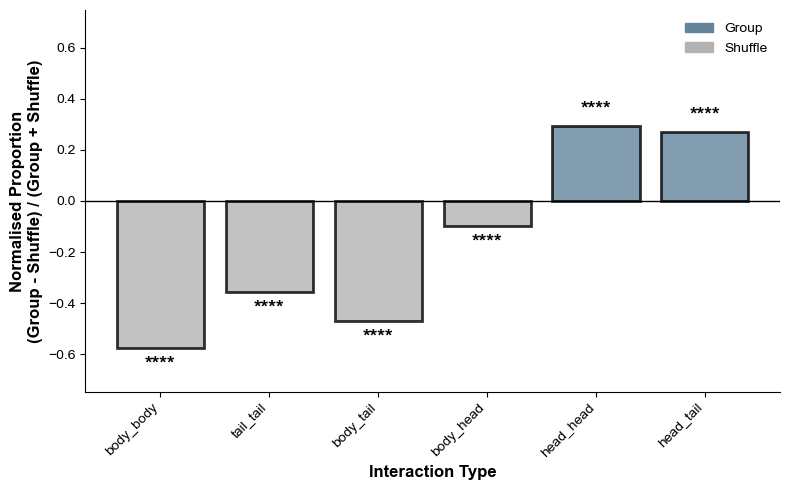

In [32]:

# ===================== NORMALISED PROPORTION (skew Group vs Shuffle) =====================
# skew = (Group - Shuffle) / (Group + Shuffle), using mean proportion per interaction type
# +1 = only in Group, -1 = only in Shuffle, 0 = equal

means = grouped.groupby(['Closest Interaction Type', 'condition'])['proportion'].mean().unstack()
skew = ((means['Group'] - means['Shuffle']) / (means['Group'] + means['Shuffle'])).reindex(order)

colours = [PALETTE['Group'] if v > 0 else PALETTE['Shuffle'] for v in skew]

plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.bar(skew.index, skew.values, color=colours, edgecolor='black', linewidth=2, alpha=0.8)
ax.axhline(0, color='black', linewidth=1)

plt.xlabel('Interaction Type', fontsize=12, fontweight='bold')
plt.ylabel('Normalised Proportion\n(Group - Shuffle) / (Group + Shuffle)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

lim = max(abs(skew).max() * 1.3, 0.1)
plt.ylim(-lim, lim)

for i, (label, v) in enumerate(skew.items()):
    stars = star_map.get(label, "")
    if stars:
        ax.text(i, v + (0.02 if v > 0 else -0.02) * lim / 0.5, stars,
                ha='center', va='bottom' if v > 0 else 'top',
                fontsize=14, fontweight='bold')

ax.legend(handles=[mpatches.Patch(color=PALETTE['Group'], label='Group'),
                   mpatches.Patch(color=PALETTE['Shuffle'], label='Shuffle')],
          frameon=False)

sns.despine()
plt.tight_layout()

plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-1/ghXpseudo/contact-type-stacked-proportion-normalised.pdf',
            format='pdf', bbox_inches='tight')
plt.show()

n videos: Group = 10, Shuffle = 100
Mann-Whitney U = 989.0, p = 3.79e-07


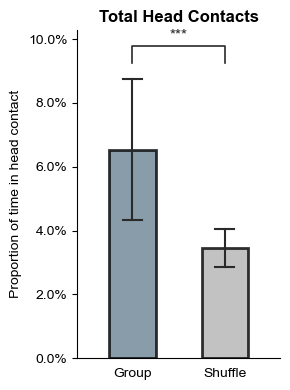

In [33]:
# ===================== TOTAL HEAD CONTACTS (per larva) =====================
# Proportion of time each larva spends in a contact where at least one node is a head
# (head_head, head_body, head_tail, body_head, tail_head ...), Group vs Shuffle.
# Uses the frame-by-frame closest-contact data (df from the first cell) so time is exact,
# then the same per-larva -> per-video averaging as the proportion-of-time cells.
import matplotlib.ticker as mticker

TOTAL_SECONDS = 3600          # fps = 1, recording = 3600 s   #

head_long = (
    df[['condition', 'file', 'frame', 'Interaction Pair', 'Closest Interaction Type']]
    .assign(
        is_head=lambda d: d['Closest Interaction Type'].astype(str).str.contains('head'),
        larva=lambda d: (
            d['Interaction Pair']
            .astype(str)
            .str.replace(r'[\(\)\[\]\s]', '', regex=True)
            .str.split(',')
        )
    )
    .explode('larva')
)
head_long['larva'] = head_long['larva'].astype(int)

# every larva seen in any contact (so larvae with contacts but no head contacts count as 0)
all_larvae_head = head_long[['condition', 'file', 'larva']].drop_duplicates()

# per larva: number of unique frames in a head contact (a frame is counted once even if the
# larva is in two head contacts at the same time - same idea as merging overlapping bouts)
head_frames = (
    head_long[head_long['is_head']]
    .drop_duplicates(['condition', 'file', 'larva', 'frame'])
    .groupby(['condition', 'file', 'larva'])
    .size()
    .reset_index(name='head_contact_seconds')
)

head_per_larva = (
    all_larvae_head
    .merge(head_frames, on=['condition', 'file', 'larva'], how='left')
    .fillna({'head_contact_seconds': 0})
)
head_per_larva['proportion'] = head_per_larva['head_contact_seconds'] / TOTAL_SECONDS

# average across larvae per video
head_per_video = (
    head_per_larva
    .groupby(['condition', 'file'])['proportion']
    .mean()
    .reset_index()
)

group_vals   = head_per_video.loc[head_per_video['condition'] == 'Group', 'proportion']
shuffle_vals = head_per_video.loc[head_per_video['condition'] == 'Shuffle', 'proportion']

stat, p = mannwhitneyu(group_vals, shuffle_vals, alternative='two-sided')
print(f'n videos: Group = {len(group_vals)}, Shuffle = {len(shuffle_vals)}')
print(f'Mann-Whitney U = {stat:.1f}, p = {p:.4g}')

def p_to_stars_head(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

fig, ax = plt.subplots(figsize=(3, 4))

sns.barplot(data=head_per_video, x='condition', y='proportion', hue='condition',
            order=HUE_ORDER, hue_order=HUE_ORDER, palette=PALETTE, legend=False,
            errorbar=('sd'), width=0.5, edgecolor='black', linewidth=2, alpha=0.8,
            capsize=0.2, err_kws={'color': '#2a2a2a', 'linewidth': 1.5}, ax=ax)

# significance bracket, placed just above the tallest error bar
bar_tops = [max(line.get_ydata()[~np.isnan(line.get_ydata())]) for line in ax.lines if len(line.get_ydata())]
y_max     = max(bar_tops) if bar_tops else head_per_video['proportion'].max()
y_tip     = y_max * 1.06
y_bracket = y_max * 1.12
stars     = p_to_stars_head(p)

ax.plot([0, 0, 1, 1], [y_tip, y_bracket, y_bracket, y_tip], color='#2a2a2a', linewidth=1.2)
ax.text(0.5, y_bracket * 1.01, stars, ha='center', va='bottom',
        fontsize=11 if stars != 'ns' else 9, color='#2a2a2a')

ax.set_title('Total Head Contacts', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Proportion of time in head contact')
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=None))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(bottom=False)
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-1/ghXpseudo/total-head-contacts.pdf', bbox_inches='tight')
plt.show()
